In [12]:
import pandas as pd
import samples_setup 

### Get data - Zooplankton

In [13]:
DataPath = '/home/sofia/Candu_postdoc/Hierarchical_Model/Zooplankton-Data/Processed Data/'

RESOLUTION = 65
SEED = 6565

### Crate ImageDataset


In [14]:
SELECTED_LIST = [
    '149um>',
    'Bosminidae',
    'Bubbles',
    'Calanoid',
    'Cladocera',
    'Copepoda',
    'Cyclopoid',
    'Daphnia',
    'Debris',
    'Duplicates',
    'Eubosmina',
    'Exoskeleton',
    'Harpacticoid',
    'MultiClass',
    'Nauplius_Copepod',
    'Partial_Copepod',
    'Partial_Daphnia',
    'Phytoplankton',
    'Rotifer',
    'Unknown'
        
    ]

dataset_selected = samples_setup.ImageDataset(
    data_directory = DataPath,
    class_names = SELECTED_LIST,
    max_class_size = 15000,
    image_resolution = 64,
    image_transforms = None,
    format_file = '.tif',
    seed = SEED
    )

### Print details


In [15]:
data_details = dataset_selected.get_dataset_details()
dataset_selected.print_dataset_details()


Total Dataset Size: 27095
Class Name: 149um> | Class Label: 0 | Count: 12073 | Prop: 0.45
Class Name: Bosminidae | Class Label: 1 | Count: 1903 | Prop: 0.07
Class Name: Bubbles | Class Label: 2 | Count: 32 | Prop: 0.00
Class Name: Calanoid | Class Label: 3 | Count: 27 | Prop: 0.00
Class Name: Cladocera | Class Label: 4 | Count: 758 | Prop: 0.03
Class Name: Copepoda | Class Label: 5 | Count: 125 | Prop: 0.00
Class Name: Cyclopoid | Class Label: 6 | Count: 46 | Prop: 0.00
Class Name: Daphnia | Class Label: 7 | Count: 1872 | Prop: 0.07
Class Name: Debris | Class Label: 8 | Count: 8401 | Prop: 0.31
Class Name: Duplicates | Class Label: 9 | Count: 5 | Prop: 0.00
Class Name: Eubosmina | Class Label: 10 | Count: 280 | Prop: 0.01
Class Name: Exoskeleton | Class Label: 11 | Count: 614 | Prop: 0.02
Class Name: Harpacticoid | Class Label: 12 | Count: 13 | Prop: 0.00
Class Name: MultiClass | Class Label: 13 | Count: 46 | Prop: 0.00
Class Name: Nauplius_Copepod | Class Label: 14 | Count: 191 | Pro

### Plot


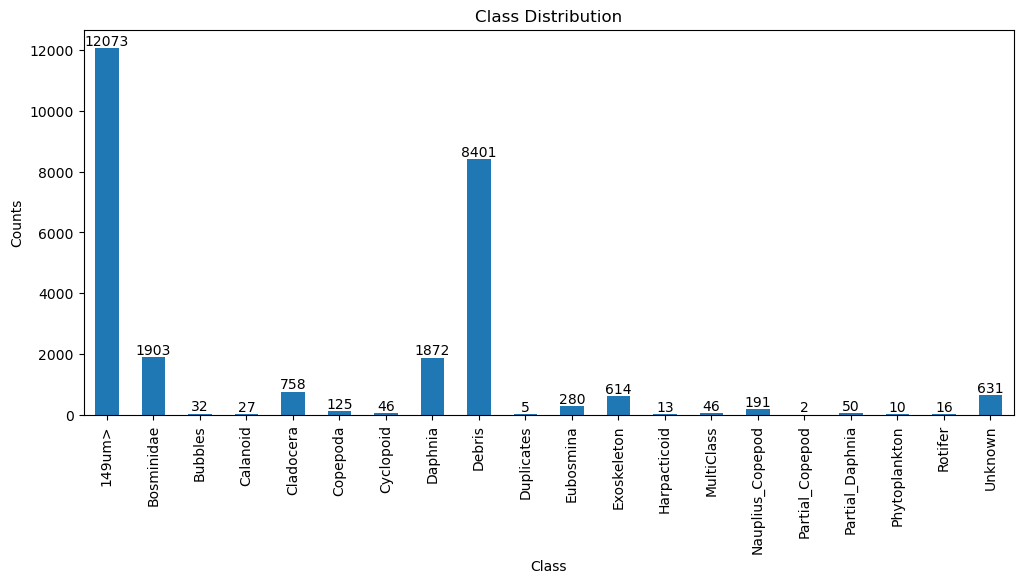

In [16]:
import matplotlib.pyplot as plt 
df = pd.DataFrame(data_details)

ax = df.plot(x='Class',y='Counts', kind='bar',legend = False, figsize=(12, 5))
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),                
        (p.get_x() + p.get_width() / 2, p.get_height()),  
        ha="center", va="bottom"                
    )

plt.ylabel('Counts')
plt.title('Class Distribution')
plt.show()

### Merge categories


In [7]:
classes_to_merge_list = [
    [
    'Guinardia_delicatula',
    'Guinardia_striata',
    'G_delicatula_external_parasite',
   ],
   [
    'Chaetoceros',
    'Chaetoceros_didymus_flagellate',   
   ]
]
new_names_list = [
    'Guinardia',
    'Chaetoceros'
]


dataset_merged =  samples_setup.merge_classes(
    dataset = dataset_selected,
    classes_to_merge_list=classes_to_merge_list,
    new_names_list=new_names_list
    )

### Print details


In [8]:
data_details_merged = dataset_merged.get_dataset_details()
dataset_merged.print_dataset_details()


Total Dataset Size: 106628
Class Name: Asterionellopsis | Class Label: 0 | Count: 1853 | Prop: 0.02
Class Name: Cerataulina | Class Label: 1 | Count: 9999 | Prop: 0.09
Class Name: Chaetoceros | Class Label: 2 | Count: 11427 | Prop: 0.11
Class Name: Corethron | Class Label: 3 | Count: 6386 | Prop: 0.06
Class Name: Coscinodiscus | Class Label: 4 | Count: 711 | Prop: 0.01
Class Name: Cylindrotheca | Class Label: 5 | Count: 9999 | Prop: 0.09
Class Name: Dactyliosolen | Class Label: 6 | Count: 9999 | Prop: 0.09
Class Name: Ditylum | Class Label: 7 | Count: 5161 | Prop: 0.05
Class Name: Ephemera | Class Label: 8 | Count: 633 | Prop: 0.01
Class Name: Eucampia | Class Label: 9 | Count: 2191 | Prop: 0.02
Class Name: Guinardia | Class Label: 10 | Count: 13667 | Prop: 0.13
Class Name: Lauderia | Class Label: 11 | Count: 295 | Prop: 0.00
Class Name: Leptocylindrus | Class Label: 12 | Count: 10000 | Prop: 0.09
Class Name: Pseudonitzschia | Class Label: 13 | Count: 4307 | Prop: 0.04
Class Name: Ske

### Plot

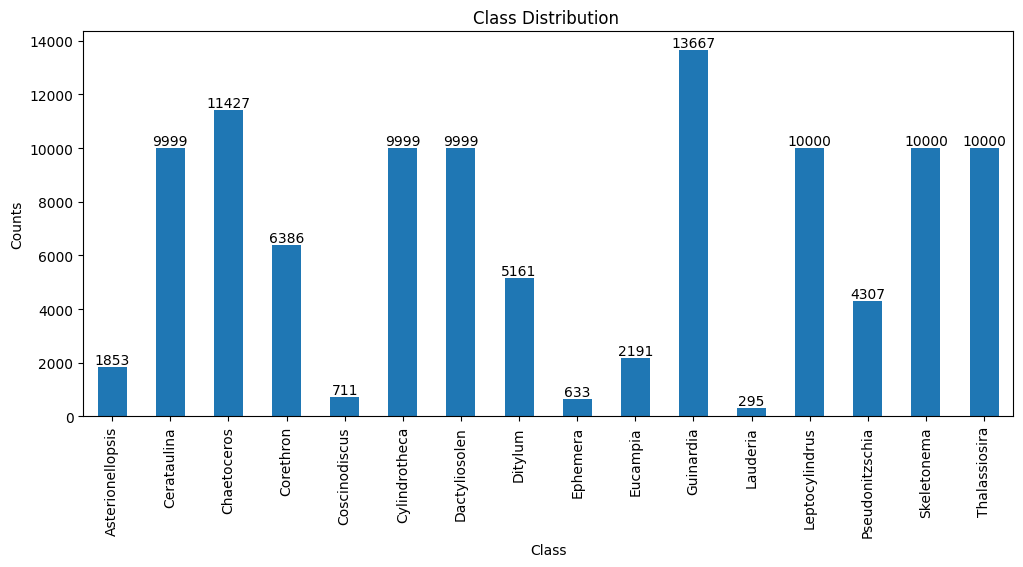

In [9]:
import matplotlib.pyplot as plt 
df = pd.DataFrame(data_details_merged)

ax = df.plot(x='Class',y='Counts', kind='bar',legend = False, figsize=(12, 5))
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),                
        (p.get_x() + p.get_width() / 2, p.get_height()),  
        ha="center", va="bottom"                
    )

plt.ylabel('Counts')
plt.title('Class Distribution ')
plt.show()